In [1]:
# Install required numerical, optimization, and visualization packages
!pip install numpy pandas scipy cvxpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style and random seed for reproducible benchmark metrics
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

print("Libraries successfully loaded.")

Libraries successfully loaded.


In [3]:
def generate_vanguard_synthetic_market(num_assets=8, seed=SEED):
    """
    Generates synthetic asset metrics including returns, volatilities,
    sector labels, and a positive semi-definite covariance matrix.
    """
    np.random.seed(seed)
    tickers = [f"ASSET_{i+1:02d}" for i in range(num_assets)]

    # Sector assignments across typical asset classes
    sectors_pool = ["Equity_US", "Equity_Intl", "Fixed_Income", "Real_Estate"]
    sectors = [sectors_pool[i % len(sectors_pool)] for i in range(num_assets)]

    # Expected annual returns (4% to 14%) and volatilities (8% to 25%)
    returns = np.random.uniform(0.04, 0.14, num_assets)
    volatilities = np.random.uniform(0.08, 0.25, num_assets)

    # Random correlation matrix converted to valid Covariance Matrix (PSD)
    raw_corr = np.random.uniform(0.15, 0.55, (num_assets, num_assets))
    corr_matrix = (raw_corr + raw_corr.T) / 2.0
    np.fill_diagonal(corr_matrix, 1.0)

    cov_matrix = np.outer(volatilities, volatilities) * corr_matrix

    # Package into a structured DataFrame
    asset_info = pd.DataFrame({
        "Ticker": tickers,
        "Sector": sectors,
        "Expected_Return": returns,
        "Volatility": volatilities
    })

    return tickers, returns, cov_matrix, asset_info

# Generate 8-asset market universe
tickers, returns, cov_matrix, asset_df = generate_vanguard_synthetic_market(num_assets=8)
print("Asset Universe Summary:")
display(asset_df)

Asset Universe Summary:


,Ticker,Sector,Expected_Return,Volatility
0,ASSET_01,Equity_US,0.077454,0.182190
1,ASSET_02,Equity_Intl,0.135071,0.200372
2,ASSET_03,Fixed_Income,0.113199,0.083499
3,ASSET_04,Real_Estate,0.099866,0.244885
4,ASSET_05,Equity_US,0.055602,0.221515
5,ASSET_06,Equity_Intl,0.055599,0.116098
6,ASSET_07,Fixed_Income,0.045808,0.110910
7,ASSET_08,Real_Estate,0.126618,0.111179


In [7]:
def solve_classical_mean_variance(returns, cov_matrix, risk_aversion=0.5, target_k=4):
    """
    Solves the Mixed-Integer Quadratic Programming (MIQP) problem:

    min  q * (x^T * Cov * x) - (R^T * x)
    s.t. sum(x) == K
         x_i in {0, 1}
    """
    n = len(returns)
    x = cp.Variable(n, boolean=True)  # Binary asset selection variable

    # Objective function
    portfolio_variance = cp.quad_form(x, cov_matrix)
    portfolio_return = returns.T @ x
    objective = cp.Minimize(risk_aversion * portfolio_variance - portfolio_return)

    # Cardinality Constraint (Select exactly K assets)
    constraints = [cp.sum(x) == target_k]

    # Solve MIQP
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS_BB, verbose=False)

    selected_vector = np.round(x.value).astype(int)

    # Calculate performance metrics
    exp_return = float(returns.T @ selected_vector)
    variance = float(selected_vector.T @ cov_matrix @ selected_vector)
    volatility = np.sqrt(variance)

    return {
        "status": prob.status,
        "optimal_cost": prob.value,
        "selection_vector": selected_vector,
        "selected_tickers": [tickers[i] for i in range(n) if selected_vector[i] == 1],
        "expected_return": exp_return,
        "volatility": volatility,
        "sharpe_ratio": exp_return / volatility if volatility > 0 else 0
    }

# Execute classical optimization
RISK_AVERSION = 0.5
TARGET_K = 4

baseline_results = solve_classical_mean_variance(
    returns, cov_matrix, risk_aversion=RISK_AVERSION, target_k=TARGET_K
)

print("\n--- CLASSICAL BASELINE RESULTS (CVXPY) ---")
print(f"Solver Status        : {baseline_results['status']}")
print(f"Optimal Minimum Cost : {baseline_results['optimal_cost']:.6f}")
print(f"Selected Vector (x)  : {baseline_results['selection_vector']}")
print(f"Selected Assets      : {baseline_results['selected_tickers']}")
print(f"Expected Return      : {baseline_results['expected_return']*100:.2f}%")
print(f"Portfolio Volatility : {baseline_results['volatility']*100:.2f}%")
print(f"Sharpe Ratio         : {baseline_results['sharpe_ratio']:.4f}")


--- CLASSICAL BASELINE RESULTS ---
Solver Status        : optimal
Optimal Minimum Cost : -0.367419
Selected Vector (x)  : [1 1 1 0 0 0 0 1]
Selected Assets      : ['ASSET_01', 'ASSET_02', 'ASSET_03', 'ASSET_08']
Expected Return      : 45.23%
Portfolio Volatility : 41.21%
Sharpe Ratio         : 1.0976


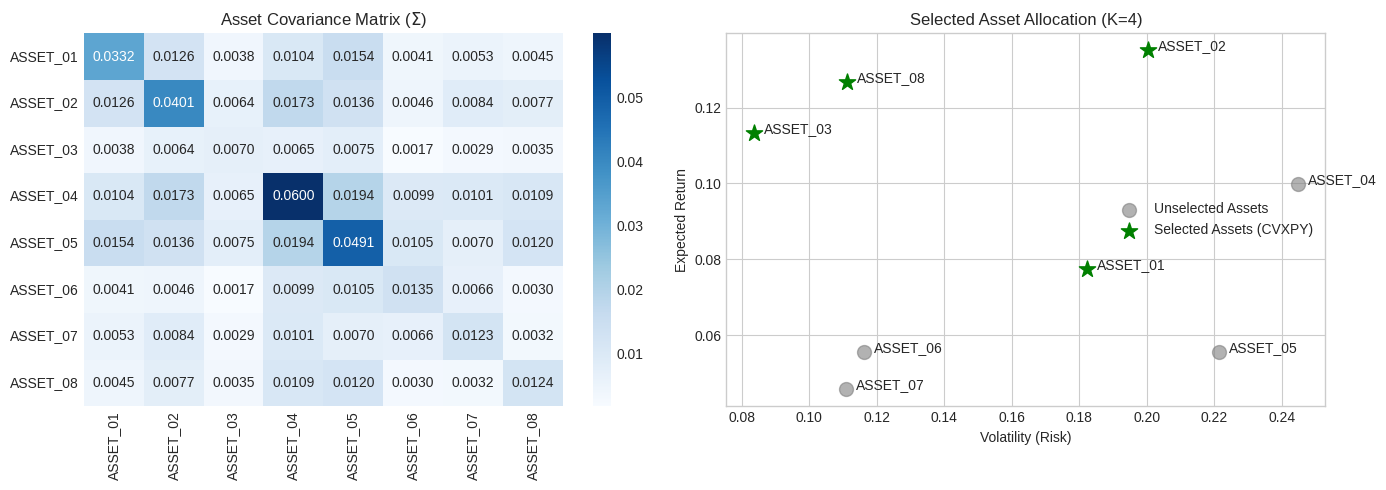

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Covariance Matrix Heatmap
sns.heatmap(cov_matrix, annot=True, fmt=".4f", xticklabels=tickers, yticklabels=tickers, cmap="Blues", ax=axes[0])
axes[0].set_title("Asset Covariance Matrix ($\\Sigma$)")

# Plot Selected Asset Returns vs Volatility
selected_indices = np.where(baseline_results["selection_vector"] == 1)[0]
unselected_indices = np.where(baseline_results["selection_vector"] == 0)[0]

axes[1].scatter(asset_df["Volatility"].iloc[unselected_indices],
                asset_df["Expected_Return"].iloc[unselected_indices],
                color="gray", label="Unselected Assets", s=100, alpha=0.6)

axes[1].scatter(asset_df["Volatility"].iloc[selected_indices],
                asset_df["Expected_Return"].iloc[selected_indices],
                color="green", label="Selected Assets (CVXPY)", s=150, marker="*")

for i, txt in enumerate(tickers):
    axes[1].annotate(txt, (asset_df["Volatility"][i]+0.003, asset_df["Expected_Return"][i]))

axes[1].set_xlabel("Volatility (Risk)")
axes[1].set_ylabel("Expected Return")
axes[1].set_title(f"Selected Asset Allocation (K={TARGET_K})")
axes[1].legend()

plt.tight_layout()
plt.show()